In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

import config as cfg

csv_file = "/home/takayuki/Desktop/summer2025/plants/data/study_area_data/0017562-250802193616735.csv"

print("Plant Species List")
for cn in cfg.CANONICAL_CLASSNAMES_LIST:
    print(cn)

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Plant Species List
Brasenia schreberi
Cabomba
Ceratophyllum demersum
Elodea canadensis
Heteranthera dubia
Hydrocharis morsus-ranae
Myriophyllum sibiricum
Myriophyllum spicatum
Najas flexilis
Nitellopsis obtusa
Nuphar variegata
Nymphaea odorata
Potamogeton crispus
Potamogeton gramineus
Potamogeton illinoensis
Potamogeton natans
Potamogeton praelongus
Potamogeton richardsonii
Potamogeton robbinsii
Ranunculus aquatilis
Vallisneria americana


/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
df = pd.read_csv(
    csv_file,
    sep='\t',        
    index_col='gbifID', 
    low_memory=False 
)

print("Headers in the CSV file:")
print(df.columns)

Headers in the CSV file:
Index(['datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class', 'order',
       'family', 'genus', 'species', 'infraspecificEpithet', 'taxonRank',
       'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='object')


In [3]:
df_geo = df.dropna(subset=['decimalLatitude', 'decimalLongitude']).copy()
print(f"Original records: {len(df)}, \nRecords with coordinates: {len(df_geo)}")

Original records: 147450, 
Records with coordinates: 117650


In [4]:
gdf_plants = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo.decimalLongitude, df_geo.decimalLatitude),
    crs="EPSG:4326"  
)

In [5]:
shape_file = "/home/takayuki/Desktop/summer2025/plants/data/study_area_data/ne_110m_admin_1_states_provinces/ne_110m_admin_1_states_provinces.shp"
try:
    states_shp = shape_file
    usa = gpd.read_file(states_shp)
    michigan_boundary = usa[usa['name'] == 'Michigan']
    print(f"Loaded shapefile for Michigan")
except Exception as e:
    print(f"Error loading shapefile: {e}")
    print("Please ensure the path to your states shapefile is correct.")
    exit()

Loaded shapefile for Michigan


In [6]:
gdf_plants_michigan = gpd.sjoin(gdf_plants, michigan_boundary, how="inner", predicate="within")
print(f"Records after filtering to Michigan boundary: {len(gdf_plants_michigan)}")

Records after filtering to Michigan boundary: 16357


Found 16357 records with coordinates located within Michigan.


/tmp/ipykernel_29468/4146432663.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(species_list)) # 'tab20' has more colors than the default


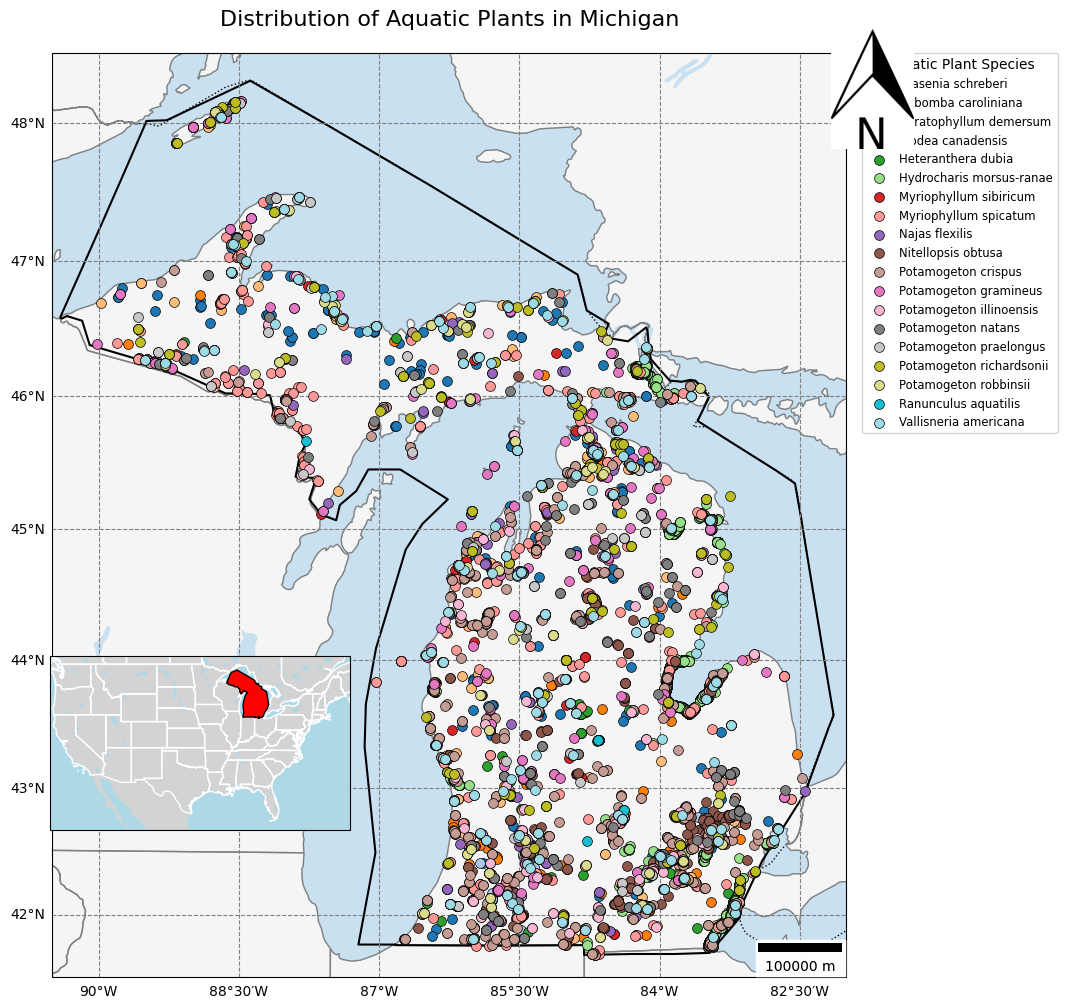

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

# --- 1. DEFINE FILE PATHS ---
# !!! IMPORTANT: UPDATE THESE TWO PATHS !!!

# Path to your downloaded GBIF occurrence data file
gbif_file_path = csv_file

# Path to the unzipped Natural Earth states shapefile
states_shapefile_path = shape_file


# --- 2. Load and Filter Data ---

# Load the tab-separated GBIF data
try:
    df = pd.read_csv(gbif_file_path, sep='\t', index_col='gbifID', low_memory=False)
except FileNotFoundError:
    print(f"ERROR: The GBIF file was not found at '{gbif_file_path}'")
    print("Please update the 'gbif_file_path' variable.")
    exit()

# Filter out records with missing coordinates and convert to a GeoDataFrame
df_geo = df.dropna(subset=['decimalLatitude', 'decimalLongitude']).copy()
gdf_plants = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo.decimalLongitude, df_geo.decimalLatitude),
    crs="EPSG:4326"  # CRS for standard latitude/longitude
)

# Load the states shapefile to get Michigan's boundary
try:
    usa = gpd.read_file(states_shapefile_path)
    michigan_boundary = usa[usa['name'] == 'Michigan']
except Exception:
    print(f"ERROR: The shapefile was not found at '{states_shapefile_path}'")
    print("Please update the 'states_shapefile_path' variable.")
    exit()

# Spatially filter the plant data to keep only points within Michigan
gdf_plants_michigan = gpd.sjoin(gdf_plants, michigan_boundary, how="inner", predicate="within")
print(f"Found {len(gdf_plants_michigan)} records with coordinates located within Michigan.")


# --- 3. Create the Map ---

# Define map projections
map_proj = ccrs.Mercator()
data_proj = ccrs.PlateCarree()

# Create a figure and main axes
fig = plt.figure(figsize=(12, 12))
ax_main = fig.add_subplot(1, 1, 1, projection=map_proj)

# Set the extent to focus on Michigan
ax_main.set_extent([-90.5, -82, 41.5, 48.5], crs=data_proj)

# Add map features from cartopy
ax_main.add_feature(cfeature.LAND, color='#f5f5f5', zorder=0)
ax_main.add_feature(cfeature.OCEAN, color='#c9e0f0', zorder=0)
ax_main.add_feature(cfeature.LAKES, color='#c9e0f0', zorder=0)
ax_main.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)
ax_main.add_feature(cfeature.STATES, edgecolor='gray', zorder=1)

# Plot the Michigan boundary for emphasis
michigan_boundary.to_crs(map_proj.proj4_init).plot(ax=ax_main, edgecolor='black', facecolor='none', linewidth=1.5, zorder=2)


# --- 4. Plot the Filtered Plant Data ---

# Use the 'species' column for the legend name, falling back to 'scientificName' if it's empty
gdf_plants_michigan['plot_name'] = gdf_plants_michigan['species'].fillna(gdf_plants_michigan['scientificName'])

# Define colors for each species for a clear legend
species_list = sorted(gdf_plants_michigan['plot_name'].unique()) # Sort for a consistent legend order
colors = plt.cm.get_cmap('tab20', len(species_list)) # 'tab20' has more colors than the default
color_map = {species: colors(i) for i, species in enumerate(species_list)}

# Plot each species group with its color
for species, data in gdf_plants_michigan.groupby('plot_name'):
    ax_main.scatter(data.geometry.x, data.geometry.y,
                    color=color_map[species],
                    label=species,
                    s=50,
                    edgecolor='black',
                    linewidth=0.5,
                    transform=data_proj,
                    zorder=10)

# Add a legend outside the map frame
legend = ax_main.legend(title='Aquatic Plant Species',
                        bbox_to_anchor=(1.02, 1),
                        loc='upper left',
                        borderaxespad=0.,
                        frameon=True,
                        fontsize='small')
legend.get_frame().set_alpha(0.8)

# Add gridlines and labels
gl = ax_main.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Add Title
ax_main.set_title('Distribution of Aquatic Plants in Michigan', fontsize=16, pad=20)


# --- 5. Create the Inset Map ---

# Position the inset map on the main map
inset_ax = fig.add_axes([0.18, 0.18, 0.25, 0.25], projection=map_proj) # [left, bottom, width, height]
inset_ax.set_extent([-125, -66, 23, 50], crs=data_proj)
inset_ax.add_feature(cfeature.LAND, color='lightgray')
inset_ax.add_feature(cfeature.OCEAN, color='lightblue')
inset_ax.add_feature(cfeature.LAKES, color='lightblue')
inset_ax.add_feature(cfeature.STATES, edgecolor='white')
inset_ax.add_geometries(michigan_boundary['geometry'], crs=data_proj, facecolor='red', edgecolor='black')
inset_ax.set_xticks([])
inset_ax.set_yticks([])


# --- 6. Add Scale Bar ---

# The North Arrow code has been removed as requested.

# Add a scale bar
scalebar = ScaleBar(1, "m", length_fraction=0.25, location='lower right',
                    scale_loc='bottom', box_alpha=0.8, fixed_value=100000)
ax_main.add_artist(scalebar)



#save/show
# plt.savefig('michigan_plant_map_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
"""
I want the legend to be outside the actual map
I also want a bar plot of the number of datapoints per species
and a bar plot of the same
"""

'\nI want the legend to be outside the actual map\nI also want a bar plot of the number of datapoints per species\nand a bar plot of the same\n'